In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from tqdm import tqdm

from generative.networks.nets import AutoencoderKL
from pipelines.flow_matching_pipeline import FlowMatchingPipeline

/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [2]:
class NPYImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = sorted(
            f for f in os.listdir(root_dir) if f.endswith(".npy")
        )

        if len(self.files) == 0:
            raise RuntimeError("No .npy files found")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x = np.load(os.path.join(self.root_dir, self.files[idx]))

        if x.ndim == 2:
            x = x[None, ...]  # (1,H,W)

        x = torch.from_numpy(x).float()

        if self.transform:
            x = self.transform(x)

        return x

In [3]:
def transform_256(x: torch.Tensor) -> torch.Tensor:
    # resize
    x = F.interpolate(
        x.unsqueeze(0),
        size=(256, 256),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)

    # normalize to [-1,1] (simple per-image)
    x = x - x.min()
    x = x / (x.max() + 1e-8)
    x = 2 * x - 1

    return x

In [4]:
train_dataset = NPYImageDataset(
    root_dir="../finetuning_sd15/v18/train/",
    transform=transform_256,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

eval_dataset = NPYImageDataset(
    root_dir="../finetuning_sd15/v18/val/",
    transform=transform_256,
)
eval_loader = DataLoader(
    eval_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = AutoencoderKL(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    num_channels=(32, 64, 128),          # 256 → 128 → 64
    num_res_blocks=2,
    attention_levels=(False, False, False),
    latent_channels=4,
).to(device)

In [ ]:
pipeline = FlowMatchingPipeline(device=device).add_vae(vae)

In [8]:
pipeline.train_vae(
    dataloader=train_loader,
    epochs=100,
    eval_dataloader=eval_loader,
    log_dir="./runs/autoencoder_kl",
    patience=3,
    min_delta=0
)

VAE Train 1/100:   0%|          | 0/841 [00:00<?, ?it/s]

VAE Eval  1/100: 100%|██████████| 24/24 [00:02<00:00,  8.84it/s]


[Epoch 1/100] train: total=0.047719 mse=0.047522 mae=0.151897 kl=1.976323 | eval:  total=0.010866 mse=0.010681 mae=0.062627 kl=1.849880
  ✅ New best eval_total=0.010866 at epoch 1 -> saved vae_best.pt


VAE Eval  2/100: 100%|██████████| 24/24 [00:01<00:00, 17.76it/s]


[Epoch 2/100] train: total=0.007023 mse=0.006872 mae=0.049560 kl=1.509978 | eval:  total=0.005642 mse=0.005520 mae=0.041005 kl=1.222386
  ✅ New best eval_total=0.005642 at epoch 2 -> saved vae_best.pt


...

VAE Eval  26/100: 100%|██████████| 24/24 [00:01<00:00, 16.52it/s]


[Epoch 26/100] train: total=0.000262 mse=0.000246 mae=0.009341 kl=0.151794 | eval:  total=0.000388 mse=0.000373 mae=0.010424 kl=0.150099
  ⏳ No improvement (best=0.000229), bad_epochs=2/3


VAE Eval  27/100: 100%|██████████| 24/24 [00:01<00:00, 16.61it/s]

[Epoch 27/100] train: total=0.000333 mse=0.000318 mae=0.010311 kl=0.148339 | eval:  total=0.000359 mse=0.000342 mae=0.011822 kl=0.164995


  ⏳ No improvement (best=0.000229), bad_epochs=3/3
🛑 Early stopping triggered. Best epoch: 24 (eval_total=0.000229)


## UNET

In [8]:
from diffusers import UNet2DModel
device = "cuda" if torch.cuda.is_available() else "cpu"
unet = UNet2DModel(
    sample_size=64,          # latent spatial size
    in_channels=4,
    out_channels=4,
    layers_per_block=2,
    block_out_channels=(128, 256, 512),
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
).to(device)
pipeline = FlowMatchingPipeline(device=device).add_unet(unet).add_vae(vae).load_vae_weights("./vae_best.pt")


# Flow matching setup

In [9]:


pipeline.train_flow_matching(
    dataloader=train_loader,
    epochs=100,
    eval_dataloader=eval_loader,
    log_dir="./runs/flow_matching_t_scaled",
    patience=5,
    min_delta=0,
    scale_t=True
)

FM Epoch 1/100:   0%|          | 0/841 [00:00<?, ?it/s]

FM Epoch 1/100: 100%|██████████| 841/841 [02:43<00:00,  5.14it/s]


[FM Epoch 1] loss: 0.274224


FM Eval  1/100: 100%|██████████| 24/24 [00:02<00:00, 11.21it/s]


  [Eval loss: 0.329756]
  ✅ New best eval_loss=0.329756 at epoch 1 -> saved unet_fm_best.pt


...

  [Eval loss: 0.382098]
  ⏳ No improvement (best=0.329756), bad_epochs=4/5


FM Epoch 6/100: 100%|██████████| 841/841 [02:44<00:00,  5.10it/s]


[FM Epoch 6] loss: 0.123247


FM Eval  6/100: 100%|██████████| 24/24 [00:02<00:00, 11.35it/s]

  [Eval loss: 0.345364]
  ⏳ No improvement (best=0.329756), bad_epochs=5/5
🛑 Early stopping triggered. Best epoch: 1 (eval_loss=0.329756)


# without config, with weights

In [1]:
from pipelines.flow_matching_pipeline import FlowMatchingPipeline
from diffusers import UNet2DModel
from generative.networks.nets import AutoencoderKL

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
vae_cfg = dict(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    num_channels=(32, 64, 128),
    num_res_blocks=2,
    attention_levels=(False, False, False),
    latent_channels=4,
)

unet_cfg = dict(
    sample_size=64,
    in_channels=4,
    out_channels=4,
    layers_per_block=2,
    block_out_channels=(128, 256, 512),
    down_block_types=("DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
)

pipe = FlowMatchingPipeline(device="cuda", t_scale=1000, model_dir="./my_run_001") \
    .build_from_configs(vae_config=vae_cfg, unet_config=unet_cfg) \
    .load_pretrained(
        vae_path="vae_best.pt",
        unet_path="unet_fm_best_t_non_scaled.pt",
        set_eval=True,
    )

pipe.unet.eval()



/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


UNet2DModel(
  (conv_in): Conv2d(4, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-05, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(12

# without config without weights

In [4]:
from pipelines.flow_matching_pipeline import FlowMatchingPipeline
from diffusers import UNet2DModel
from generative.networks.nets import AutoencoderKL

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
vae_cfg = dict(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    num_channels=(32, 64, 128),
    num_res_blocks=2,
    attention_levels=(False, False, False),
    latent_channels=4,
)

unet_cfg = dict(
    sample_size=64,
    in_channels=4,
    out_channels=4,
    layers_per_block=2,
    block_out_channels=(128, 256, 512),
    down_block_types=("DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
)

pipe = FlowMatchingPipeline(device="cuda", t_scale=1000, model_dir="./my_run_001") \
    .build_from_configs(vae_config=vae_cfg, unet_config=unet_cfg) \

pipe.unet.eval()



UNet2DModel(
  (conv_in): Conv2d(4, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-05, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(12

# with config without weights

In [5]:
from pipelines.flow_matching_pipeline import StableFlowMatchingPipeline
from diffusers import UNet2DModel
from generative.networks.nets import AutoencoderKL

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"


pipe = StableFlowMatchingPipeline(device="cuda", t_scale=1000, model_dir="./my_run_001") \
    .build_from_configs(vae_json="vae_config.json", unet_json="unet_config.json") \

pipe.unet.eval()



UNet2DModel(
  (conv_in): Conv2d(4, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-05, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(12

# With json config and with weights

In [6]:
from pipelines.flow_matching_pipeline import FlowMatchingPipeline
from diffusers import UNet2DModel
from generative.networks.nets import AutoencoderKL

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"


pipe = FlowMatchingPipeline(device="cuda", t_scale=1000, model_dir="./my_run_001") \
    .load_from_pipeline_folder_auto("training_t_scaled/")
    # .build_from_configs(vae_json="my_run_001/VAE/config.json", unet_json="my_run_001/UNET/config.json") \

pipe.unet.eval()



UNet2DModel(
  (conv_in): Conv2d(4, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-05, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(12

In [ ]:
# start from Gaussian noise in latent space
z = torch.randn(2, 4, 64, 64, device="cuda")

zs = []

for i in range(50):
    t = torch.full((2,), i / 50, device="cuda")
    v = pipe.unet(z, t).sample
    z = z + v / 50

    if i in {0, 10, 25, 49}:
        zs.append(z.clone())

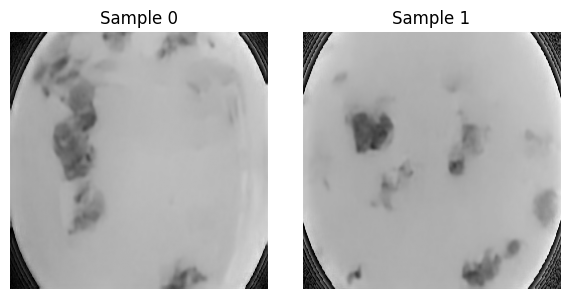

In [3]:
import matplotlib.pyplot as plt

pipe.vae.eval()

with torch.no_grad():
    # Decode latents -> image space
    x_gen = pipe.vae.decode(z)   # (B, C, H, W)

    # Map from [-1, 1] to [0, 1] for visualization
    x_vis = (x_gen + 1) / 2
    x_vis = x_vis.clamp(0, 1)

# Move to CPU for plotting
x_vis = x_vis.cpu()

# Plotting
fig, axes = plt.subplots(1, x_vis.shape[0], figsize=(6, 3))

for i in range(x_vis.shape[0]):
    img = x_vis[i]

    # If grayscale (C=1)
    if img.shape[0] == 1:
        axes[i].imshow(img[0], cmap="gray")
    else:
        axes[i].imshow(img.permute(1, 2, 0))

    axes[i].axis("off")
    axes[i].set_title(f"Sample {i}")

plt.tight_layout()
plt.show()

# Training

In [1]:
from pipelines.flow_matching_pipeline import FlowMatchingPipeline


pipe = FlowMatchingPipeline(
    device="cuda",
    t_scale=1000,
    model_dir="./training_t_scaled"
).build_from_configs(
    vae_json="./vae_config.json",
    unet_json="./unet_config.json"
).load_vae_weights(
    "./vae_best.pt"
).save_vae_weights()

/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [6]:
pipe.train_flow_matching(
    dataloader=train_loader,
    epochs=50,
    eval_dataloader=eval_loader,
    log_dir=f"{pipe.model_dir}/runs/flow_matching_t_scaled_v2",
    patience=None,
    min_delta=0,
    
)

FM Epoch 1/50: 100%|██████████| 841/841 [02:42<00:00,  5.19it/s]


[FM Epoch 1] loss: 0.276808


FM Epoch 2/50: 100%|██████████| 841/841 [02:42<00:00,  5.19it/s]


[FM Epoch 2] loss: 0.188786


FM Epoch 3/50: 100%|██████████| 841/841 [02:41<00:00,  5.20it/s]


...

[FM Epoch 48] loss: 0.078601


FM Epoch 49/50: 100%|██████████| 841/841 [02:42<00:00,  5.19it/s]


[FM Epoch 49] loss: 0.082893


FM Epoch 50/50: 100%|██████████| 841/841 [02:42<00:00,  5.18it/s]


[FM Epoch 50] loss: 0.083605


In [4]:
from pipelines.flow_matching_pipeline import StableFlowMatchingPipeline


pipe = StableFlowMatchingPipeline(
    device="cuda", 
    t_scale=1000, 
    model_dir="./serious_runs/stable_training_t_scaled"
    ).build_from_configs(
        vae_json="./vae_config.json",
        unet_json="./serious_runs/stable_training_t_scaled/UNET/config.json"
    ).load_pretrained(
        vae_path="vae_best.pt",
        unet_path="serious_runs/stable_training_t_scaled/UNET/unet_fm_epoch_150.pt",
        set_eval=True,
    )
z = pipe.sample_latents_euler(
    steps=50,
    batch_size=4,
)

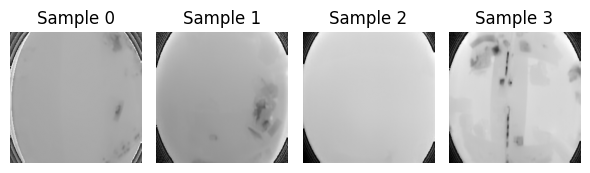

In [6]:
import matplotlib.pyplot as plt
import torch

pipe.vae.eval()

with torch.no_grad():
    # Decode latents -> image space
    x_gen = pipe.vae.decode(z)   # (B, C, H, W)

    # Map from [-1, 1] to [0, 1] for visualization
    x_vis = (x_gen + 1) / 2
    x_vis = x_vis.clamp(0, 1)

# Move to CPU for plotting
x_vis = x_vis.cpu()

# Plotting
fig, axes = plt.subplots(1, x_vis.shape[0], figsize=(6, 3))

for i in range(x_vis.shape[0]):
    img = x_vis[i]

    # If grayscale (C=1)
    if img.shape[0] == 1:
        axes[i].imshow(img[0], cmap="gray")
    else:
        axes[i].imshow(img.permute(1, 2, 0))

    axes[i].axis("off")
    axes[i].set_title(f"Sample {i}")

plt.tight_layout()
plt.show()